# 2.4. Heisenberg의 불확정성 원리

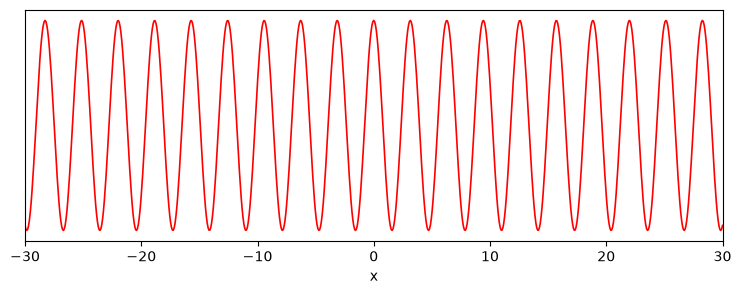

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-30, 30, 801)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(x, np.cos(2 * x), color="red", lw=1.2)
ax.set_xlim(-30, 30)
ax.set_yticks([])
ax.set_xlabel("x")
plt.show()

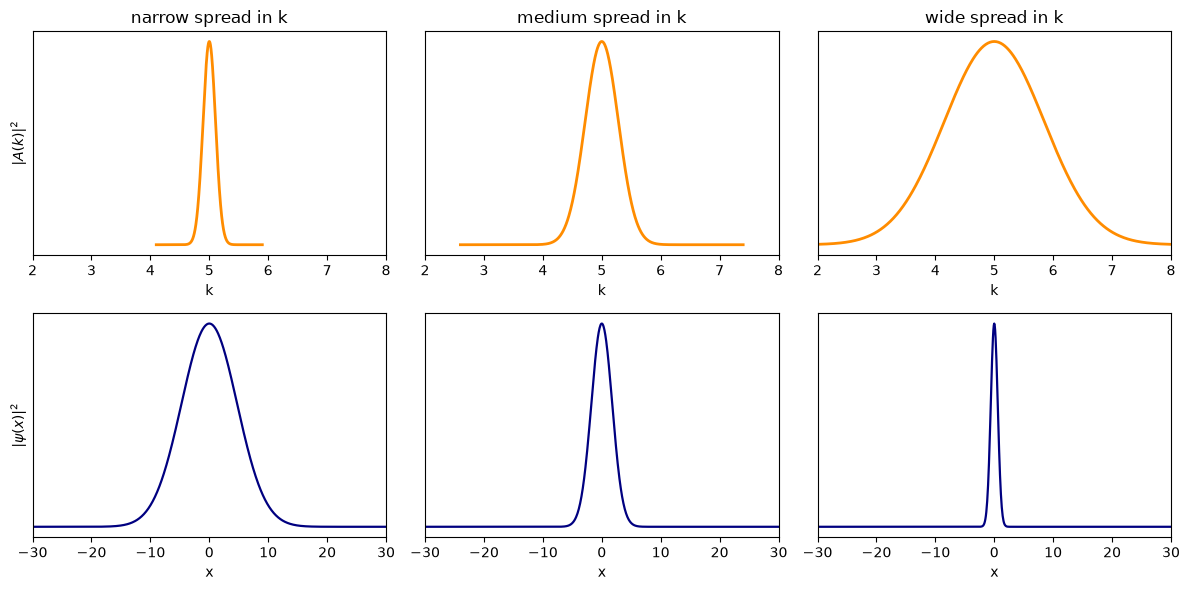

In [2]:
def wave_packet(k0, sigma_k):
    # 중심 파수 k0 주변에 폭 sigma_k의 파동 패킷을 만든다
    k = np.linspace(k0 - 6 * sigma_k, k0 + 6 * sigma_k, 801)
    A = np.exp(-((k - k0) ** 2) / (2 * sigma_k**2))
    psi = (A[:, None] * np.exp(1j * k[:, None] * x[None, :])).sum(axis=0)
    return k, A, psi


fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for j, (sk, label) in enumerate([(0.15, "narrow"), (0.4, "medium"), (1.2, "wide")]):
    k, A, psi = wave_packet(5.0, sk)

    axes[0, j].plot(k, A**2 / (A**2).max(), color="darkorange", lw=2)
    axes[0, j].set_xlim(2, 8)
    axes[0, j].set_yticks([])
    axes[0, j].set_xlabel("k")
    axes[0, j].set_title(f"{label} spread in k")

    axes[1, j].plot(
        x, (np.abs(psi) ** 2) / (np.abs(psi) ** 2).max(), color="navy", lw=1.6
    )
    axes[1, j].set_xlim(-30, 30)
    axes[1, j].set_yticks([])
    axes[1, j].set_xlabel("x")

axes[0, 0].set_ylabel("$|A(k)|^2$")
axes[1, 0].set_ylabel("$|\\psi(x)|^2$")

plt.tight_layout()
plt.show()

In [3]:
def stdev(grid, prob):
    prob = prob / np.trapezoid(prob, grid)
    mean = np.trapezoid(grid * prob, grid)
    var = np.trapezoid((grid - mean) ** 2 * prob, grid)
    return np.sqrt(var)


x = np.linspace(-60, 60, 6000)

print(f"{'sigma_k':>8} {'Δk':>8} {'Δx':>8} {'Δx*Δk':>8}")

for sk in [0.1, 0.2, 0.4, 0.8, 1.6]:
    k, A, psi = wave_packet(5, sk)
    Dk = stdev(k, np.abs(A) ** 2)
    Dx = stdev(x, np.abs(psi) ** 2)
    print(f"{sk:8.1f} {Dk:8.4f} {Dx:8.4f} {Dx*Dk:8.4f}")

 sigma_k       Δk       Δx    Δx*Δk
     0.1   0.0707   7.0711   0.5000
     0.2   0.1414   3.5355   0.5000
     0.4   0.2828   1.7678   0.5000
     0.8   0.5657   0.8839   0.5000
     1.6   1.1314   0.4419   0.5000


In [4]:
from scipy.constants import hbar, m_e

print(f"{'물체':<12} {'Δx':>10} {'최소 Δv':>12}")

for name, m, Dx in [
    ("원자 속 전자", m_e, 1e-10),
    ("1 um 상자 속 전자", m_e, 1e-6),
    ("야구공", 0.15, 1e-10),
]:
    Dv = hbar / (2 * m * Dx)
    print(f"{name:<12} {Dx:>10.0e} m {Dv:12.3e} m/s")

물체                   Δx        최소 Δv
원자 속 전자           1e-10 m    5.788e+05 m/s
1 um 상자 속 전자      1e-06 m    5.788e+01 m/s
야구공               1e-10 m    3.515e-24 m/s
